# Genetic Algorithms: Evolutionary Computing

A genetic algorithm solves hard search problems by copying the rough shape of natural selection.

John Holland helped formalize genetic algorithms in the 1960s and 1970s as a way to search huge spaces without checking every possibility. They have been used for scheduling, route planning, design optimization, game agents, art, and engineering search.

We start with a population of random solutions, score them, keep the stronger ones, breed them, mutate them, and repeat. Over many generations, terrible solutions can evolve into useful ones.

In this notebook, the playground is the Traveling Salesperson Problem: find a short route through 50 cities.

<details>
<summary>Big idea</summary>

A genetic algorithm does not need to know the perfect answer. It only needs a way to score candidates and a way to create new candidates from old ones.

</details>

## 1. Mental Model

A genetic algorithm has four main moves:

- **Population**: many candidate solutions.
- **Fitness**: a score that says how good each candidate is.
- **Selection**: better candidates are more likely to become parents.
- **Crossover and mutation**: parents create children, and children get small random changes.

For TSP, one candidate solution is a full ordering of cities.

<details>
<summary>TSP hint</summary>

A route is valid if it visits every city exactly once and returns to the start. The shorter the total distance, the fitter the route.

</details>

## 2. Build the Objects

We will model evolution directly:

- `City` stores a point on the map.
- `Route` stores one candidate tour.
- `GAConfig` stores population size, mutation rate, and generation count.
- `GenerationSnapshot` records best, average, and worst route distance.
- `GeneticTSPSolver` runs selection, crossover, mutation, and elitism.

<details>
<summary>Implementation hint</summary>

Crossover is tricky for TSP because a child route must not repeat cities. We will use ordered crossover: copy a slice from one parent, then fill the remaining positions from the other parent.

</details>

**Object model.** Define `City`, the named objects used by the next examples.


In [ ]:
from dataclasses import dataclass

import math

import random

import matplotlib.pyplot as plt

import numpy as np

@dataclass(frozen=True)
class City:
    name: str
    x: float
    y: float

    def distance_to(self, other: "City") -> float:
        return math.hypot(self.x - other.x, self.y - other.y)


**Object model.** Define `Route`, `GAConfig`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class Route:
    order: tuple[int, ...]

    def distance(self, cities: list[City]) -> float:
        total = 0.0
        for current, next_city in zip(self.order, self.order[1:] + self.order[:1]):
            total += cities[current].distance_to(cities[next_city])
        return total

    def is_valid(self, city_count: int) -> bool:
        return len(self.order) == city_count and set(self.order) == set(range(city_count))

@dataclass(frozen=True)
class GAConfig:
    population_size: int = 180
    generations: int = 260
    elite_count: int = 8
    tournament_size: int = 5
    mutation_rate: float = 0.18
    capture_every: int = 20


**Trace model.** Define `GenerationSnapshot`, the structure used to capture replayable algorithm state.


In [ ]:
@dataclass(frozen=True)
class GenerationSnapshot:
    generation: int
    best_route: Route
    best_distance: float
    average_distance: float
    worst_distance: float


**State model.** Define `TSPWorld`, the data structure the lesson will operate on.


In [ ]:
class TSPWorld:
    def __init__(self, cities: list[City]):
        self.cities = cities

    @classmethod
    def random_cities(cls, count: int = 50, seed: int = 42) -> "TSPWorld":
        rng = np.random.default_rng(seed)
        points = rng.uniform(0, 100, size=(count, 2))
        cities = [City(name=f"C{index:02}", x=float(x), y=float(y)) for index, (x, y) in enumerate(points)]
        return cls(cities)

    @property
    def city_count(self) -> int:
        return len(self.cities)

    def distance(self, route: Route) -> float:
        return route.distance(self.cities)


**Algorithm engine.** Define `GeneticTSPSolver`, the class that runs the main simulation or algorithm.


In [ ]:
class GeneticTSPSolver:
    def __init__(self, world: TSPWorld, config: GAConfig, seed: int = 7):
        self.world = world
        self.config = config
        self.rng = random.Random(seed)
        self.snapshots: list[GenerationSnapshot] = []

    def random_route(self) -> Route:
        order = list(range(self.world.city_count))
        self.rng.shuffle(order)
        return Route(tuple(order))

    def initial_population(self) -> list[Route]:
        return [self.random_route() for _ in range(self.config.population_size)]

    def rank_population(self, population: list[Route]) -> list[tuple[float, Route]]:
        return sorted((self.world.distance(route), route) for route in population)

    def tournament_select(self, ranked_population: list[tuple[float, Route]]) -> Route:
        contestants = self.rng.sample(ranked_population, self.config.tournament_size)
        return min(contestants, key=lambda item: item[0])[1]

    def ordered_crossover(self, parent_a: Route, parent_b: Route) -> Route:
        city_count = self.world.city_count
        start, end = sorted(self.rng.sample(range(city_count), 2))
        child: list[int | None] = [None] * city_count
        child[start:end] = parent_a.order[start:end]

        fill_values = [city for city in parent_b.order if city not in child]
        fill_index = 0
        for index in range(city_count):
            if child[index] is None:
                child[index] = fill_values[fill_index]
                fill_index += 1

        route = Route(tuple(city for city in child if city is not None))
        if not route.is_valid(city_count):
            raise RuntimeError("Crossover produced an invalid route.")
        return route

    def mutate(self, route: Route) -> Route:
        order = list(route.order)
        if self.rng.random() < self.config.mutation_rate:
            left, right = sorted(self.rng.sample(range(len(order)), 2))
            order[left], order[right] = order[right], order[left]
        return Route(tuple(order))

    def snapshot(self, generation: int, ranked_population: list[tuple[float, Route]]) -> GenerationSnapshot:
        distances = [distance for distance, _ in ranked_population]
        return GenerationSnapshot(
            generation=generation,
            best_route=ranked_population[0][1],
            best_distance=ranked_population[0][0],
            average_distance=float(np.mean(distances)),
            worst_distance=ranked_population[-1][0],
        )

    def next_generation(self, ranked_population: list[tuple[float, Route]]) -> list[Route]:
        elites = [route for _, route in ranked_population[: self.config.elite_count]]
        children = list(elites)

        while len(children) < self.config.population_size:
            parent_a = self.tournament_select(ranked_population)
            parent_b = self.tournament_select(ranked_population)
            child = self.ordered_crossover(parent_a, parent_b)
            children.append(self.mutate(child))

        return children

    def run(self) -> list[GenerationSnapshot]:
        population = self.initial_population()
        ranked_population = self.rank_population(population)
        self.snapshots = [self.snapshot(0, ranked_population)]

        for generation in range(1, self.config.generations + 1):
            population = self.next_generation(ranked_population)
            ranked_population = self.rank_population(population)
            should_capture = generation % self.config.capture_every == 0 or generation == self.config.generations
            if should_capture:
                self.snapshots.append(self.snapshot(generation, ranked_population))

        return self.snapshots


**Visual helper.** Define `route_coordinates`, `plot_route`, which turns state into something students can inspect.


In [ ]:
def route_coordinates(route: Route, cities: list[City]) -> tuple[list[float], list[float]]:
    ordered_cities = [cities[index] for index in route.order]
    closed_route = ordered_cities + [ordered_cities[0]]
    return [city.x for city in closed_route], [city.y for city in closed_route]

def plot_route(world: TSPWorld, route: Route, title: str, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    x_values, y_values = route_coordinates(route, world.cities)
    city_x = [city.x for city in world.cities]
    city_y = [city.y for city in world.cities]
    ax.plot(x_values, y_values, color="#E76F51", linewidth=1.4, alpha=0.9)
    ax.scatter(city_x, city_y, color="#264653", s=28, zorder=3)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


**Visual helper.** Define `plot_fitness_history`, which turns state into something students can inspect.


In [ ]:
def plot_fitness_history(snapshots: list[GenerationSnapshot]) -> None:
    generations = [snapshot.generation for snapshot in snapshots]
    best = [snapshot.best_distance for snapshot in snapshots]
    average = [snapshot.average_distance for snapshot in snapshots]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(generations, best, label="best route", color="#2A9D8F", linewidth=2.5)
    ax.plot(generations, average, label="population average", color="#E9C46A", linewidth=2)
    ax.set_title("Fitness improves as route distance shrinks")
    ax.set_xlabel("generation")
    ax.set_ylabel("route distance")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.show()


## 3. Generate 50 Cities

The Traveling Salesperson Problem asks for the shortest loop that visits every city exactly once and returns home.

We will make 50 random cities on an x-y plane. The first routes will be messy because they are just random permutations.

<details>
<summary>Fitness hint</summary>

This is a minimization problem. A lower route distance means a fitter candidate.

</details>

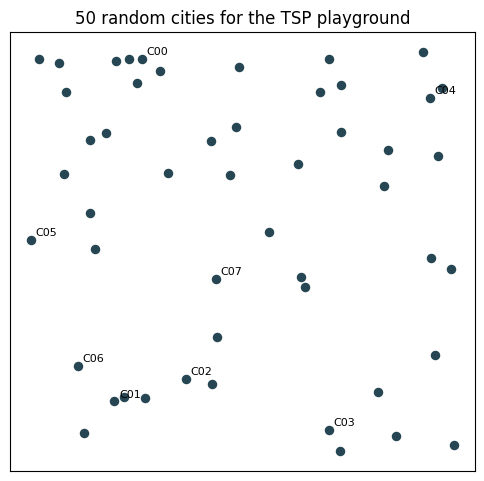

City count: 50
First five cities:
C00: (25.1, 94.7)
C01: (18.9, 17.9)
C02: (35.0, 23.1)
C03: (67.0, 11.5)
C04: (89.6, 85.8)


In [2]:
world = TSPWorld.random_cities(count=50, seed=12)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter([city.x for city in world.cities], [city.y for city in world.cities], color="#264653", s=34)
for city in world.cities[:8]:
    ax.text(city.x + 1, city.y + 1, city.name, fontsize=8)
ax.set_title("50 random cities for the TSP playground")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

print(f"City count: {world.city_count}")
print("First five cities:")
for city in world.cities[:5]:
    print(f"{city.name}: ({city.x:.1f}, {city.y:.1f})")

## 4. Run Evolution

The solver will keep a few elite routes, select parents with tournaments, combine routes with ordered crossover, and randomly mutate some children.

Over time, the best route should get shorter.

<details>
<summary>Selection hint</summary>

Tournament selection samples a few candidates and picks the best one as a parent. It rewards fitness without always choosing only the current champion.

</details>

**Example state.** Create `config`, `solver`, `snapshots`, `initial`, and related helpers, the concrete values used in the next run.


In [ ]:
config = GAConfig(
    population_size=180,
    generations=260,
    elite_count=8,
    tournament_size=5,
    mutation_rate=0.18,
    capture_every=20,
)

solver = GeneticTSPSolver(world=world, config=config, seed=21)

snapshots = solver.run()

initial = snapshots[0]

final = snapshots[-1]

improvement = 100 * (initial.best_distance - final.best_distance) / initial.best_distance

print(f"Captured snapshots: {len(snapshots)}")

print(f"Initial best distance: {initial.best_distance:.2f}")

print(f"Final best distance  : {final.best_distance:.2f}")

print(f"Improvement          : {improvement:.1f}%")

print()

print("generation | best distance | average distance | worst distance")

print("-" * 62)


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
for snapshot in snapshots[::2]:
    print(
        f"{snapshot.generation:>10} | "
        f"{snapshot.best_distance:>13.2f} | "
        f"{snapshot.average_distance:>16.2f} | "
        f"{snapshot.worst_distance:>14.2f}"
    )


## 5. Watch the Route Untangle

The first best route is still chaotic. Later best routes become shorter and more locally organized.

The algorithm is not guaranteed to find the global optimum, but it usually finds a much better route than random guessing.

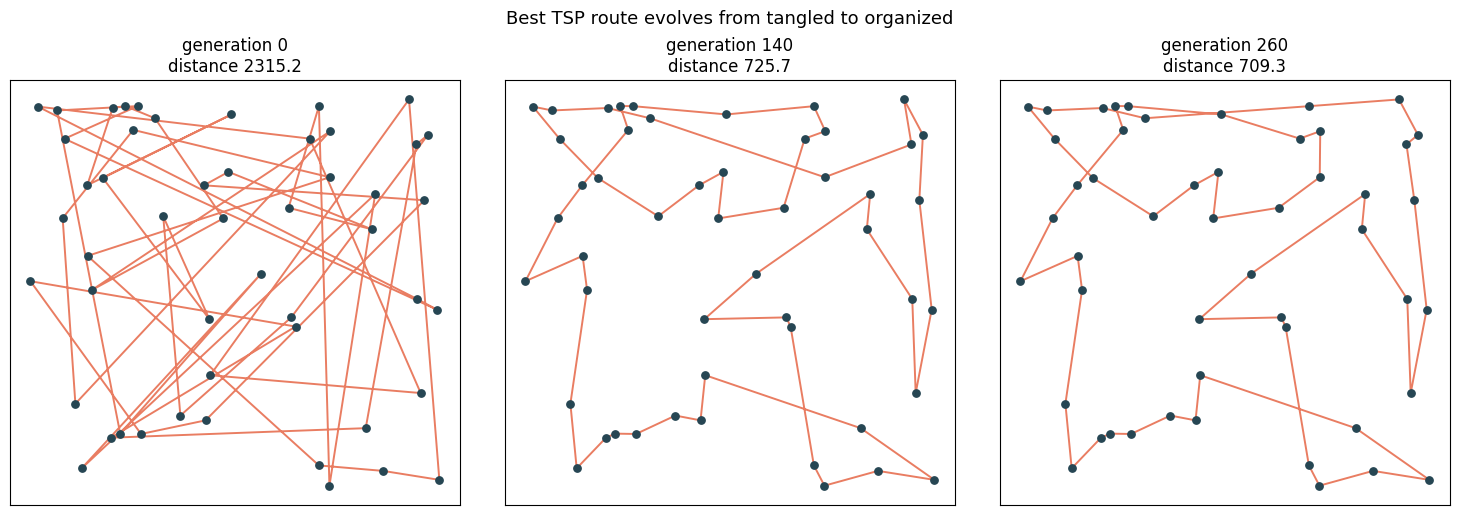

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, snapshot in zip(axes, [snapshots[0], snapshots[len(snapshots) // 2], snapshots[-1]]):
    plot_route(
        world,
        snapshot.best_route,
        title=f"generation {snapshot.generation}\ndistance {snapshot.best_distance:.1f}",
        ax=ax,
    )

fig.suptitle("Best TSP route evolves from tangled to organized", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

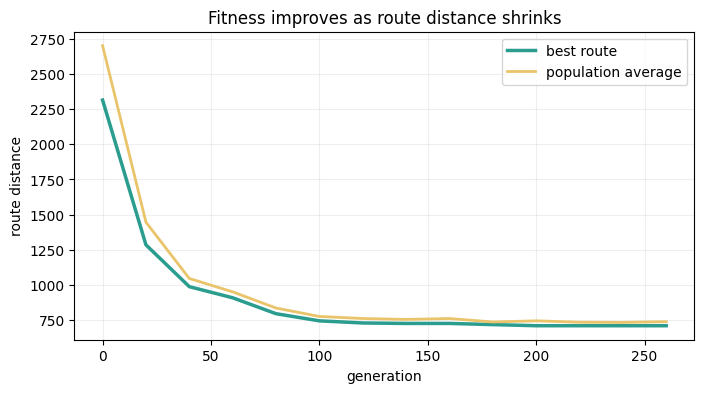

In [5]:
plot_fitness_history(snapshots)

## 6. Animate the Best Route

The snapshots can be animated so the route visibly changes as the population evolves.

<details>
<summary>Animation hint</summary>

The animation uses saved best routes instead of every generation. That keeps the notebook fast while still showing the evolutionary trend.

</details>

In [7]:
from IPython.display import HTML
from matplotlib import animation

fig, ax = plt.subplots(figsize=(5.5, 5.5))


def update_route_frame(frame_index: int):
    ax.clear()
    snapshot = snapshots[frame_index]
    plot_route(
        world,
        snapshot.best_route,
        title=f"generation {snapshot.generation} | distance {snapshot.best_distance:.1f}",
        ax=ax,
    )
    return ax.lines + ax.collections


route_animation = animation.FuncAnimation(
    fig,
    update_route_frame,
    frames=len(snapshots),
    interval=420,
    blit=False,
)
plt.close(fig)
HTML(route_animation.to_jshtml())

## 7. Replay Evolution

A route plot shows geometry. A replay table shows selection pressure: the best and average distances both shrink as the population improves.

In [8]:
class EvolutionReplay:
    def __init__(self, snapshots: list[GenerationSnapshot]):
        self.snapshots = snapshots

    def show(self) -> None:
        first_distance = self.snapshots[0].best_distance
        for snapshot in self.snapshots:
            improvement = 100 * (first_distance - snapshot.best_distance) / first_distance
            print(
                f"generation={snapshot.generation:>3} "
                f"best={snapshot.best_distance:>7.1f} "
                f"avg={snapshot.average_distance:>7.1f} "
                f"improvement={improvement:>5.1f}%"
            )


EvolutionReplay(snapshots).show()

generation=  0 best= 2315.2 avg= 2702.0 improvement=  0.0%
generation= 20 best= 1284.9 avg= 1446.2 improvement= 44.5%
generation= 40 best=  987.4 avg= 1045.7 improvement= 57.4%
generation= 60 best=  908.2 avg=  950.4 improvement= 60.8%
generation= 80 best=  794.9 avg=  835.3 improvement= 65.7%
generation=100 best=  744.0 avg=  775.3 improvement= 67.9%
generation=120 best=  728.9 avg=  760.7 improvement= 68.5%
generation=140 best=  725.7 avg=  754.2 improvement= 68.7%
generation=160 best=  725.7 avg=  760.6 improvement= 68.7%
generation=180 best=  717.3 avg=  735.9 improvement= 69.0%
generation=200 best=  709.3 avg=  744.1 improvement= 69.4%
generation=220 best=  709.3 avg=  734.2 improvement= 69.4%
generation=240 best=  709.3 avg=  732.8 improvement= 69.4%
generation=260 best=  709.3 avg=  738.2 improvement= 69.4%


## 8. Playground: Mutation Rate

Mutation keeps the population from becoming too similar too early.

Too little mutation can get stuck. Too much mutation can destroy useful structure. The sweet spot depends on the problem and the rest of the algorithm.

**Simulation helper.** Define `run_mutation_experiment`, which advances the model and records behavior.


In [ ]:
def run_mutation_experiment(mutation_rate: float, seed: int) -> GenerationSnapshot:
    experiment_config = GAConfig(
        population_size=90,
        generations=120,
        elite_count=6,
        tournament_size=5,
        mutation_rate=mutation_rate,
        capture_every=120,
    )
    experiment_solver = GeneticTSPSolver(world=world, config=experiment_config, seed=seed)
    return experiment_solver.run()[-1]

mutation_rates = [0.02, 0.18, 0.45]

mutation_results = [
    run_mutation_experiment(rate, seed=100 + index)
    for index, rate in enumerate(mutation_rates)
]

for rate, snapshot in zip(mutation_rates, mutation_results):
    print(f"mutation_rate={rate:<4} final_best_distance={snapshot.best_distance:.1f}")

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar([str(rate) for rate in mutation_rates], [snapshot.best_distance for snapshot in mutation_results], color="#2A9D8F")

ax.set_title("Mutation-rate experiment")

ax.set_xlabel("mutation rate")


**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
ax.set_ylabel("final best distance after 120 generations")

ax.grid(axis="y", alpha=0.2)

plt.show()


## 9. Why This Is Heuristic Optimization

A genetic algorithm does not prove it found the shortest possible TSP route. Instead, it searches intelligently when brute force is impossible.

For 50 cities, the number of possible tours is astronomically large. Evolution gives us a practical strategy:

- preserve useful structure,
- combine strong candidates,
- keep enough randomness to explore,
- stop when the solution is good enough.

<details>
<summary>Optimization note</summary>

A lower final distance is better, but different random seeds can produce different routes. Genetic algorithms are stochastic, so repeated runs are normal in real optimization work.

</details>

## 10. What You Should Remember

- A chromosome is one candidate solution. Here, it is a city ordering.
- Fitness measures solution quality. Here, shorter distance means better fitness.
- Selection lets strong candidates influence the next generation.
- Crossover combines parent traits while preserving a valid route.
- Mutation injects randomness so the population can escape early bad habits.
- Genetic algorithms are useful when exact search is too expensive and a strong approximate answer is valuable.

<details>
<summary>Course connection</summary>

This lesson follows the same simulation pattern as the others: define state, define rules, run iterations, record snapshots, and visualize how local updates create global behavior.

</details>

## Visual Trace + Rigor Studio

**Problem frame.** Evolve candidate solutions using selection, crossover, and mutation.

**Interactive animation target.** Animate population fitness distribution, parents, offspring, and mutation events.

**Correctness handle.** Selection pressure increases high-fitness representation while mutation preserves variation.

**Complexity handle.** Budget-driven; cost is population size times generations times fitness cost.

**Failure mode to test.** Low diversity causes premature convergence; high mutation prevents refinement.

**Studio task.** Run low and high mutation rates and compare both best fitness and diversity.


In [ ]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
